
Step size h = 0.01
Coefficient matrix:
[[ 1.    0.01]
 [-0.01  1.  ]]
Eigenvalues: [1.+0.01j 1.-0.01j]
Magnitudes: [1.00005 1.00005]
Solution may not be Entirely Stable ;)

Step size h = 0.02
Coefficient matrix:
[[ 1.    0.02]
 [-0.02  1.  ]]
Eigenvalues: [1.+0.02j 1.-0.02j]
Magnitudes: [1.00019998 1.00019998]
Solution may not be Entirely Stable ;)

Step size h = 0.03
Coefficient matrix:
[[ 1.    0.03]
 [-0.03  1.  ]]
Eigenvalues: [1.+0.03j 1.-0.03j]
Magnitudes: [1.0004499 1.0004499]
Solution may not be Entirely Stable ;)

Step size h = 0.05
Coefficient matrix:
[[ 1.    0.05]
 [-0.05  1.  ]]
Eigenvalues: [1.+0.05j 1.-0.05j]
Magnitudes: [1.00124922 1.00124922]
Solution may not be Entirely Stable ;)

Step size h = 0.1
Coefficient matrix:
[[ 1.   0.1]
 [-0.1  1. ]]
Eigenvalues: [1.+0.1j 1.-0.1j]
Magnitudes: [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)

Step size h = 0.2
Coefficient matrix:
[[ 1.   0.2]
 [-0.2  1. ]]
Eigenvalues: [1.+0.2j 1.-0.2j]
Magnitudes: [1.0198039 

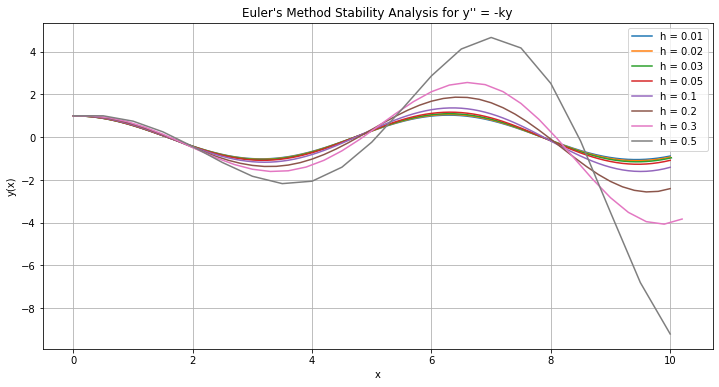

In [3]:
import numpy as np
import matplotlib.pyplot as plt

k = 1.0
x_start = 0
x_end = 10
y0 = 1.0
v0 = 0.0

h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

def coefficient_matrix(h, k):
    return np.array([
        [1,   h],
        [-h*k, 1]
    ])

def euler_second_order(h, k, x_start, x_end, y0, v0):
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    y_values[0] = y0
    v_values[0] = v0

    for i in range(1, len(x_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    return x_values, y_values, v_values

plt.figure(figsize=(12, 6))

for h in h_values:
    A = coefficient_matrix(h, k)

    eigenvalues = np.linalg.eigvals(A)
    magnitudes = np.abs(eigenvalues)

    print(f"\nStep size h = {h}")
    print("Coefficient matrix:")
    print(A)
    print("Eigenvalues:", eigenvalues)
    print("Magnitudes:", magnitudes)

    if np.all(magnitudes < 1):
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")

    x_values, y_values, v_values = euler_second_order(h, k, x_start, x_end, y0, v0)

    plt.plot(x_values, y_values, label=f'h = {h}')

plt.xlabel('x')
plt.ylabel('y(x)')
plt.title("Euler's Method Stability Analysis for y'' = -ky")
plt.legend()
plt.grid(True)
plt.show()